# Fine-Tuning Llama 3 into a Veterinary Assistant

**Authors:** Emanuele Minotti, Stefano Romano — KTH ID2223 *Scalable Machine
Learning and Deep Learning*, Lab 2.

This notebook implements the full pipeline that turns a quantized Llama 3 base
model into a domain-specialized pet-care assistant that runs on CPU-only
hardware.

## Pipeline

| Stage | What happens |
|---|---|
| 1. Setup | Install Unsloth, mount Google Drive for checkpoints |
| 2. Model | Load `Meta-Llama-3.1-8B-Instruct` in 4-bit (NF4) and attach LoRA adapters |
| 3. Instruction tuning | Supervised fine-tuning on a 10k slice of FineTome-100k |
| 4. Domain tuning | Second SFT pass on a small curated veterinary dialogue set |
| 5. Evaluation | Validation loss / perplexity every 50 steps, plus a manual benchmark |
| 6. Export | Merge adapters to 16-bit, convert to GGUF (q8_0) for CPU inference |

## Design decisions

- **4-bit quantization + LoRA (`r=32`, `alpha=32`, rsLoRA).** Only ~1% of the
  8B parameters are trainable, which is what makes the run fit in the 16 GB of a
  free Colab T4.
- **500 training steps.** A deliberate trade-off: enough adaptation to move the
  validation curve, short enough to finish inside Colab's runtime limit.
- **Checkpoint every 50 steps to Google Drive.** Colab sessions get recycled;
  checkpoints make the run resumable instead of restartable.
- **Loss on completions only.** `train_on_responses_only` masks the user turns
  so the model learns to answer, not to imitate prompts.
- **GGUF export.** The Hugging Face Space serving the model has no GPU, so the
  merged weights are quantized to 8-bit GGUF for `llama.cpp` inference.

Two smaller configurations (Llama-3.2-1B and Llama-3.2-3B) were trained with the
same notebook to compare scaling behaviour; their metrics are collected in
[`docs/evaluation.md`](../docs/evaluation.md).

## 1. Environment setup and persistent storage

Google Drive is mounted so that checkpoints and the exported model survive a
runtime disconnect. `OUTPUT_DIR` and `VETAI_DATASET_PATH` are the only two
paths to change when running this notebook elsewhere.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

# --- Configuration -----------------------------------------------------------
OUTPUT_DIR = "/content/drive/MyDrive/llama3-8b-vetai"
VETAI_DATASET_PATH = f"{OUTPUT_DIR}/vetai_dataset_100.jsonl"

# Hugging Face repo used for the merged / GGUF export. Authenticate with
# `huggingface_hub.login()` or the HF_TOKEN environment variable - never inline
# a token in the notebook.
HF_REPO = "stromano02/model"

# Set to True to continue from the latest checkpoint in OUTPUT_DIR.
RESUME_FROM_CHECKPOINT = False

Mounted at /content/drive


Unsloth is installed from the nightly branch: it ships the patched Llama kernels
and the 4-bit loading path used below.

In [ ]:
%%capture
# Unsloth nightly ships the patched Llama kernels used below; --no-deps keeps
# Colab's preinstalled torch/CUDA build untouched.
!pip install unsloth
!pip uninstall unsloth -y
!pip install --upgrade --no-cache-dir --no-deps \
    git+https://github.com/unslothai/unsloth.git@nightly \
    git+https://github.com/unslothai/unsloth-zoo.git
!pip install -U transformers huggingface_hub

## 2. Load the base model in 4-bit

`Meta-Llama-3.1-8B-Instruct` is loaded with NF4 4-bit quantization so that the
weights, activations and optimizer state fit in the 16 GB of a Colab T4. The
context window is capped at 2048 tokens, which covers the vast majority of the
training conversations without wasting compute on padding.

Unsloth exposes pre-quantized mirrors of the Llama / Mistral / Gemma / Phi
families; see https://huggingface.co/unsloth for the full list.

In [3]:
from unsloth import FastLanguageModel

MODEL_NAME = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
max_seq_length = 2048  # RoPE scaling is handled internally by Unsloth
dtype = None  # None = auto-detect (float16 on T4, bfloat16 on Ampere+)
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.6: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


### LoRA adapters

Instead of updating all 8B weights, LoRA adapters are attached to the attention
and MLP projections. With `r=32` this trains ~84M parameters (about 1% of the
model). Rank-stabilized LoRA (`use_rslora=True`) keeps the update scale stable
at higher ranks.

In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=32,
    lora_dropout=0,  # 0 is the optimized path
    bias="none",  # "none" is the optimized path
    use_gradient_checkpointing="unsloth",  # ~30% less VRAM, 2x larger batches
    random_state=3407,
    use_rslora=True,
    loftq_config=None,
)

Unsloth 2025.11.6 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


## 3. Data preparation

Training data comes from [FineTome-100k](https://huggingface.co/datasets/mlabonne/FineTome-100k),
a ShareGPT-style instruction dataset. A 10k slice is used to keep the run inside
the Colab time budget.

The conversations are converted from ShareGPT's `(from, value)` schema to the
Hugging Face `(role, content)` schema and rendered with the `llama-3.1` chat
template, which produces the special-token layout the base model was trained on:

```
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Hello!<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Hey there! How are you?<|eot_id|>
```

In [ ]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(tokenizer, chat_template="llama-3.1")


def formatting_prompts_func(examples):
    """Render each conversation with the Llama 3.1 chat template."""
    texts = [
        tokenizer.apply_chat_template(
            convo, tokenize=False, add_generation_prompt=False
        )
        for convo in examples["conversations"]
    ]
    return {"text": texts}


dataset = load_dataset("mlabonne/FineTome-100k", split="train[:10000]")

`standardize_sharegpt` normalizes the role names, then a 90/10 split gives a
held-out set for validation loss and perplexity.

In [ ]:
from unsloth.chat_templates import standardize_sharegpt

dataset = standardize_sharegpt(dataset)
dataset = dataset.map(formatting_prompts_func, batched=True)
dataset = dataset.train_test_split(test_size=0.1)

## 4. Instruction tuning

TRL's [`SFTTrainer`](https://huggingface.co/docs/trl/sft_trainer) runs the
supervised fine-tuning stage. The configuration is driven by Colab's
constraints:

- `max_steps=500` — fits the free-tier runtime limit while still converging.
- `save_steps=50` with `save_total_limit=1` — resumable without filling Drive.
- `eval_steps=50` — validation loss is sampled often enough to see overfitting.
- `per_device_train_batch_size=1` + `gradient_accumulation_steps=8` — effective
  batch size of 8 at 8B scale on a single T4.
- `load_best_model_at_end=True` — the exported model is the best checkpoint, not
  the last one.

In [ ]:
from transformers import DataCollatorForSeq2Seq, TrainingArguments
from trl import SFTTrainer
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer),
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        output_dir=OUTPUT_DIR,
        max_steps=500,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        warmup_steps=5,
        learning_rate=1e-4,
        weight_decay=0.01,
        lr_scheduler_type="linear",
        optim="adamw_8bit",
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=1,
        seed=3407,
        report_to="none",
        # Checkpointing: survive a Colab disconnect without filling Drive.
        save_strategy="steps",
        save_steps=50,
        save_total_limit=1,
        # Evaluation: validation loss -> perplexity every 50 steps.
        eval_strategy="steps",
        eval_steps=50,
        per_device_eval_batch_size=2,
        load_best_model_at_end=True,
    ),
)

`train_on_responses_only` masks the loss on the user turns, so gradients come
only from the assistant completions.

In [ ]:
from unsloth.chat_templates import train_on_responses_only

INSTRUCTION_PART = "<|start_header_id|>user<|end_header_id|>\n\n"
RESPONSE_PART = "<|start_header_id|>assistant<|end_header_id|>\n\n"

trainer = train_on_responses_only(
    trainer,
    instruction_part=INSTRUCTION_PART,
    response_part=RESPONSE_PART,
)

Sanity check on the masking: the first decode shows the full example, the second
replaces every masked label (`-100`) with a space. Only the assistant turn should
survive in the second output.

In [9]:
tokenizer.decode(trainer.train_dataset[5]["input_ids"])

"<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nDescribe the working of a recursive function and analyze its time complexity. Explain how memoization can optimize the recursive function's performance, providing a practical example.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nA recursive function is a function that calls itself to solve a problem. It breaks the problem down into smaller and more manageable sub-problems, solving each sub-problem only once, stores their results, and uses the stored results to construct the solution to the original problem. \n\nLet's consider the problem of calculating the Factorial of a number 'n', i.e., n!.\n\nWithout Memoization:\n```\nfunction factorial(n) {\n    if(n == 0 || n == 1) return 1; \n    return n * factorial(n - 1);\n}\n```\nIn the above function, the time complexity is O(n) 

In [10]:
space = tokenizer(" ", add_special_tokens=False).input_ids[0]
tokenizer.decode(
    [space if x == -100 else x for x in trainer.train_dataset[5]["labels"]]
)

"                                                                  A recursive function is a function that calls itself to solve a problem. It breaks the problem down into smaller and more manageable sub-problems, solving each sub-problem only once, stores their results, and uses the stored results to construct the solution to the original problem. \n\nLet's consider the problem of calculating the Factorial of a number 'n', i.e., n!.\n\nWithout Memoization:\n```\nfunction factorial(n) {\n    if(n == 0 || n == 1) return 1; \n    return n * factorial(n - 1);\n}\n```\nIn the above function, the time complexity is O(n) because it makes 'n' recursive calls.\n\nMemoization is a technique of caching and reusing previously computed results to speed up complex computations. It optimizes a recursive function's performance by keeping track of the previously solved solutions, which prevents those solutions from being computed again.\n\nHere's the factorial function implemented with memoization:\n`

The system and user prompts are correctly masked out.

In [11]:
trainer_stats = trainer.train(resume_from_checkpoint=RESUME_FROM_CHECKPOINT)

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,000 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 83,886,080 of 8,114,147,328 (1.03% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss


## 5. Domain adaptation (VetAI)

A second, much shorter SFT pass specializes the instruction-tuned adapters on a
curated set of ~100 veterinary dialogues (pet health, nutrition, emergency
triage). The learning rate is dropped to `5e-5` for a single epoch: enough to
shift tone and domain vocabulary, small enough to avoid catastrophic forgetting
of general conversational ability.

The dataset is a JSONL file with one `messages` conversation per line; see
[`data/README.md`](../data/README.md) for the schema.

In [12]:
from datasets import load_dataset
from transformers import DataCollatorForSeq2Seq, TrainingArguments
from trl import SFTTrainer
from unsloth import is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only

vetai_dataset = load_dataset("json", data_files=VETAI_DATASET_PATH, split="train")


def format_vetai(batch):
    """Render the `messages` field with the same chat template as stage 1."""
    return {
        "text": [
            tokenizer.apply_chat_template(
                item, tokenize=False, add_generation_prompt=False
            )
            for item in batch["messages"]
        ]
    }


vetai_dataset = vetai_dataset.map(format_vetai, batched=True)
vetai_dataset = vetai_dataset.train_test_split(test_size=0.1)

trainer_vetai = SFTTrainer(
    model=model,  # continue from the instruction-tuned adapters
    tokenizer=tokenizer,
    train_dataset=vetai_dataset["train"],
    eval_dataset=vetai_dataset["test"],
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    data_collator=DataCollatorForSeq2Seq(tokenizer),
    args=TrainingArguments(
        output_dir=OUTPUT_DIR,
        num_train_epochs=1,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=2,
        warmup_steps=2,
        learning_rate=5e-5,  # low LR: refine tone without forgetting
        optim="adamw_8bit",
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=1,
        save_strategy="no",
        eval_strategy="epoch",
        report_to="none",
    ),
)

trainer_vetai = train_on_responses_only(
    trainer_vetai,
    instruction_part=INSTRUCTION_PART,
    response_part=RESPONSE_PART,
)

trainer_vetai.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting quick VetAI refinement...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 88 | Num Epochs = 1 | Total steps = 44
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 2 x 1) = 2
 "-____-"     Trainable parameters = 83,886,080 of 8,114,147,328 (1.03% trained)


Epoch,Training Loss,Validation Loss
1,1.612500,1.543397


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Refinement completed!


## 6. Metrics

Perplexity is derived from the held-out loss as `exp(eval_loss)`. The plot below
is the source of the 8B curve reported in
[`docs/evaluation.md`](../docs/evaluation.md).

--- BASELINE RESULTS ---
Lowest Validation Loss: 0.6474162936210632
Best Perplexity: 1.9105980220854124


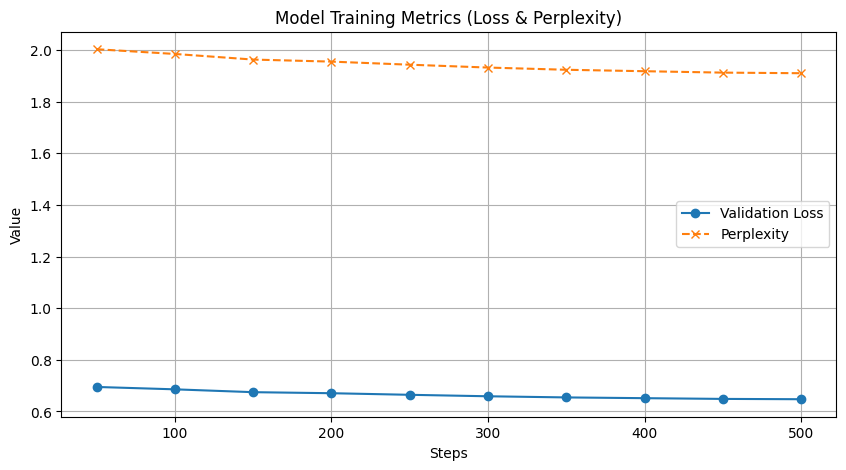

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)
eval_data = history.dropna(subset=["eval_loss"]).copy()

if eval_data.empty:
    raise ValueError("No validation metrics found - check eval_strategy='steps'.")

eval_data["perplexity"] = np.exp(eval_data["eval_loss"])

print(f"Lowest validation loss: {eval_data['eval_loss'].min():.4f}")
print(f"Best perplexity:        {eval_data['perplexity'].min():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eval_data["step"], eval_data["eval_loss"], marker="o", label="Validation loss")
ax.plot(
    eval_data["step"],
    eval_data["perplexity"],
    marker="x",
    linestyle="--",
    label="Perplexity",
)
ax.set(xlabel="Steps", ylabel="Value", title="Validation loss and perplexity")
ax.legend()
ax.grid(True)
plt.show()

## 7. Inference

`min_p=0.1` with `temperature=1.5` keeps generations varied without letting
low-probability tokens through; see
https://x.com/menhguin/status/1826132708508213629 for the rationale.

In [14]:
from transformers import TextStreamer

FastLanguageModel.for_inference(model)  # 2x faster inference path


def generate(prompt, max_new_tokens=128, stream=False):
    """Run a single-turn chat completion against the fine-tuned model."""
    inputs = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=True,
        add_generation_prompt=True,  # required for generation
        return_tensors="pt",
    ).to("cuda")

    streamer = TextStreamer(tokenizer, skip_prompt=True) if stream else None
    outputs = model.generate(
        input_ids=inputs,
        streamer=streamer,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        temperature=1.5,
        min_p=0.1,
    )
    return tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]


generate("Continue the fibonacci sequence: 1, 1, 2, 3, 5, 8,", max_new_tokens=64)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


['<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nContinue the fibonnaci sequence: 1, 1, 2, 3, 5, 8,<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n11, 18, 29,<|eot_id|>']

`TextStreamer` prints the generation token by token instead of waiting for the
full completion.

In [15]:
_ = generate("Continue the fibonacci sequence: 1, 1, 2, 3, 5, 8,", stream=True)

8, 13, 21<|eot_id|>


## 8. Saving the adapters

`save_pretrained` stores **only the LoRA adapters** (a few hundred MB), not the
full model. The merged 16-bit and GGUF exports are produced further down.

In [16]:
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

('/content/drive/MyDrive/llama3-8b-vetai/tokenizer_config.json',
 '/content/drive/MyDrive/llama3-8b-vetai/special_tokens_map.json',
 '/content/drive/MyDrive/llama3-8b-vetai/chat_template.jinja',
 '/content/drive/MyDrive/llama3-8b-vetai/tokenizer.json')

To reload the adapters in a fresh runtime, load the same base model and point
`from_pretrained` at `OUTPUT_DIR`.

In [17]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=OUTPUT_DIR,  # base model + adapters saved above
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)
FastLanguageModel.for_inference(model)

_ = generate("Describe a tall tower in the capital of France.", stream=True)

The tower stands tall at an impressive 324 meters. Built from reinforced concrete and steel, it was completed in 1889 during the World's Fair that was held in Paris. It has been a symbol of France and one of its most iconic landmarks ever since.<|eot_id|>


## 9. Merge to 16-bit and push to the Hub

The adapters are merged back into the base weights so the model can be consumed
by runtimes that do not know about PEFT. Authentication comes from
`huggingface_hub.login()` or the `HF_TOKEN` environment variable.

Alternative `save_method` values: `merged_4bit` for int4, `lora` for
adapters-only.

In [18]:
model.save_pretrained_merged(OUTPUT_DIR, tokenizer, save_method="merged_16bit")
model.push_to_hub_merged(HF_REPO, tokenizer, save_method="merged_16bit")

Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [13:37<00:00, 204.27s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/llama3-8b-vetai`


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [14:52<00:00, 223.24s/it]


Unsloth: Merge process complete. Saved to `/content/stromano02/model`


## 10. GGUF export for CPU inference

The merged weights are converted to GGUF with 8-bit quantization (`q8_0`), the
format `llama.cpp` needs to serve the model on the CPU-only Hugging Face Space.

In [19]:
import os

if not os.path.isdir("llama.cpp"):
    !git clone --depth 1 https://github.com/ggerganov/llama.cpp.git

QUANTIZATION_METHOD = "q8_0"
GGUF_OUTFILE = f"{OUTPUT_DIR}/llama-3.1-8b-vetai-{QUANTIZATION_METHOD}.gguf"

!python llama.cpp/convert_hf_to_gguf.py {OUTPUT_DIR} \
    --outfile {GGUF_OUTFILE} \
    --outtype {QUANTIZATION_METHOD}

INFO:gguf.gguf_writer:Writing the following files:
INFO:gguf.gguf_writer:/content/drive/MyDrive/llama3-8b-vetai/llama-3.1-8b-vetai-q8_0.gguf: n_tensors = 292, total_size = 8.5G
INFO:hf-to-gguf:Model successfully exported to /content/drive/MyDrive/llama3-8b-vetai/llama-3.1-8b-vetai-q8_0.gguf


In [ ]:
model.push_to_hub_gguf(HF_REPO, tokenizer, quantization_method="q8_0")

## 11. Results

The same notebook was run with three base models to measure how capacity and
LoRA rank affect downstream quality. Every run used 500 steps with evaluation
every 50 steps.

| Model | LoRA rank | LoRA alpha | LR | Batch | Grad. accum. | Lowest val loss | Best perplexity |
|---|---|---|---|---|---|---|---|
| Llama-3.2-1B-Instruct | 16 | 16 | 2e-4 | 2 | 4 | 0.8906 | 2.4366 |
| Llama-3.2-3B-Instruct | 16 | 16 | 2e-4 | 2 | 4 | 0.7266 | 2.0680 |
| Meta-Llama-3.1-8B-Instruct | 32 | 32 | 1e-4 | 1 | 8 | **0.6474** | **1.9106** |

Both metrics improve monotonically with model capacity: -15% perplexity from 1B
to 3B and a further -7.6% from 3B to 8B.

| Llama-3.2-1B | Llama-3.2-3B | Meta-Llama-3.1-8B |
|:---:|:---:|:---:|
| ![1B validation curves](../docs/results/1b.png) | ![3B validation curves](../docs/results/3b.png) | ![8B validation curves](../docs/results/8b.png) |

## 12. Qualitative benchmark

Beyond loss and perplexity, the three checkpoints were compared on a fixed set
of five prompts probing conceptual clarity, transitive reasoning, concision,
empathetic tone and arithmetic. The scoring rubric, the scores and the full
model responses are documented in
[`docs/evaluation.md`](../docs/evaluation.md).

## Conclusion

The two-stage recipe — instruction tuning on FineTome-100k followed by a short,
low-learning-rate pass on curated veterinary dialogues — produces an assistant
that keeps Llama 3.1's conversational fluency while adopting a cautious,
non-diagnostic tone appropriate for pet-health questions. Validation loss and
perplexity improve consistently with model capacity, and the 8B configuration
was the one exported to GGUF and deployed.

Full metrics and benchmark transcripts: [`docs/evaluation.md`](../docs/evaluation.md).